# Challenge 1 — Solar Yield Prediction

**Goal:** Train an XGBoost regressor to predict daily solar energy yield (PVOUT, kWh/kWp/day) for Australian cities using weather observations, then save the artifacts for use by a LangChain ReAct agent.

## Pipeline Overview

```
Global Solar Atlas TIFF  +  Kaggle weatherAUS.csv
              ↓
    Rasterio PVOUT extraction per city (target)
    Geocoding → 45/46 cities resolved
              ↓
    Train: 2009 weather data  |  Holdout: 2010 weather data
    Feature engineering, label encoding
              ↓
    XGBoost Regressor (baseline → Optuna-tuned)
              ↓
    Saved artifacts: xgb_model.json, encoders.pkl,
                     city_pvout.pkl, feature_cols.pkl,
                     holdout_weather.csv
```

**Key decisions:**
- 2009/2010 chosen for best `Sunshine` coverage (~30 cities, 36–37% missing)
- `Location` excluded from features to avoid data leakage (PVOUT is city-constant)
- Honest R² ≈ 0.58 — capped by 45 discrete target values across 16K+ rows

## 1. Setup & Data Loading

Load the raw `weatherAUS.csv` (145,460 rows, 2007–2017, 49 Australian cities). Add a `Year` column for downstream splitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/raw")
WEATHER_CSV = DATA_DIR / "weatherAUS.csv"
SOLAR_DIR = (
    DATA_DIR / "Australia_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF"
)

df_all = pd.read_csv(WEATHER_CSV, parse_dates=["Date"])
df_all["Year"] = df_all["Date"].dt.year
print(
    f"Total rows: {len(df_all)} | Date range: {df_all['Date'].min().date()} to {df_all['Date'].max().date()}"
)

Total rows: 145460 | Date range: 2007-11-01 to 2017-06-25


## 2. Exploratory Data Analysis

Identify missing-value patterns across the full dataset and examine `Sunshine` coverage by year — the most important feature and the primary driver of year selection for training.

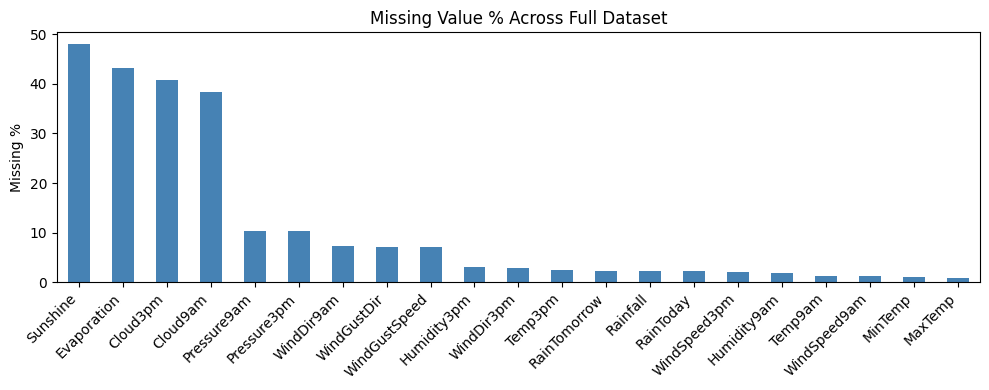

In [2]:
missing_pct = df_all.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Missing Value % Across Full Dataset")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

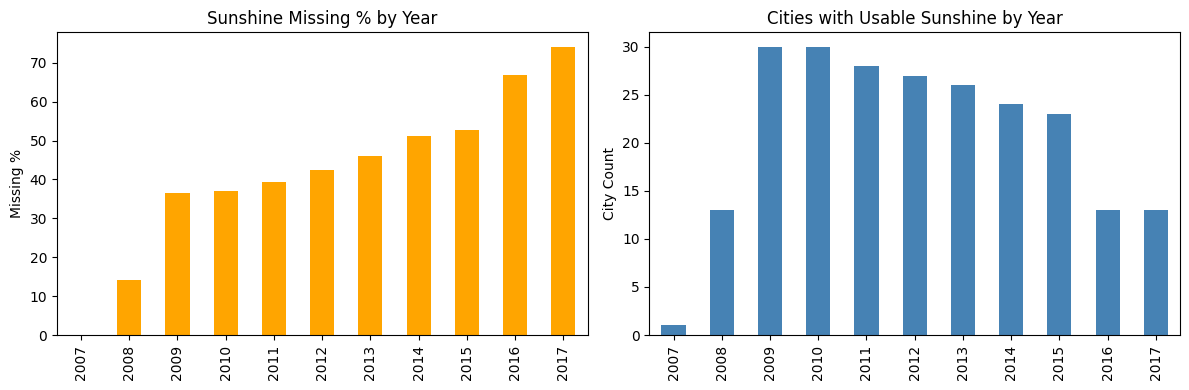

      missing_pct  cities_with_sunshine
Year                                   
2007          0.0                     1
2008         14.2                    13
2009         36.6                    30
2010         37.1                    30
2011         39.3                    28
2012         42.4                    27
2013         46.1                    26
2014         51.2                    24
2015         52.8                    23
2016         66.9                    13
2017         74.1                    13


In [3]:
sunshine_by_year = (
    df_all.groupby("Year")["Sunshine"].apply(lambda x: x.isnull().mean() * 100).round(1)
)

cities_with_sunshine = df_all.groupby("Year").apply(
    lambda x: (
        x.groupby("Location")["Sunshine"].apply(lambda s: s.isnull().mean() < 0.5)
    ).sum()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sunshine_by_year.plot(kind="bar", ax=axes[0], color="orange")
axes[0].set_title("Sunshine Missing % by Year")
axes[0].set_ylabel("Missing %")
axes[0].set_xlabel("")

cities_with_sunshine.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Cities with Usable Sunshine by Year")
axes[1].set_ylabel("City Count")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

print(
    pd.DataFrame(
        {"missing_pct": sunshine_by_year, "cities_with_sunshine": cities_with_sunshine}
    )
)

## 3. Train / Holdout Split

Split by year: **2009 → train**, **2010 → holdout**. Both years have the best `Sunshine` coverage (~30 cities, 36–37% missing). Drop `Date`, `Year`, and `RainTomorrow` (the original classification target) before modelling.

In [4]:
TRAIN_YEAR = 2009
HOLDOUT_YEAR = 2010

df_train = df_all[df_all["Year"] == TRAIN_YEAR].copy()
df_holdout = df_all[df_all["Year"] == HOLDOUT_YEAR].copy()

for df in [df_train, df_holdout]:
    df["Month"] = df["Date"].dt.month
    df["DayOfYear"] = df["Date"].dt.dayofyear

print(f"Train   : {df_train.shape}  | cities: {df_train['Location'].nunique()}")
print(f"Holdout : {df_holdout.shape} | cities: {df_holdout['Location'].nunique()}")

for name, df in [
    (f"{TRAIN_YEAR} Train", df_train),
    (f"{HOLDOUT_YEAR} Holdout", df_holdout),
]:
    missing = (df.isnull().mean() * 100).round(1)
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f"\n=== {name} ===")
    print(missing)

df_holdout_raw = df_holdout.copy()  # preserve before encoding

Train   : (16789, 26)  | cities: 46
Holdout : (16782, 26) | cities: 46

=== 2009 Train ===
Sunshine         36.6
Cloud3pm         34.6
Evaporation      34.0
Cloud9am         33.2
Pressure9am      10.4
Pressure3pm      10.4
WindGustDir      10.2
WindGustSpeed    10.2
WindDir9am        8.2
WindDir3pm        3.4
WindSpeed3pm      2.6
WindSpeed9am      2.4
Humidity3pm       1.8
Humidity9am       1.7
Temp3pm           1.6
Temp9am           1.4
RainToday         1.2
MinTemp           1.2
Rainfall          1.2
RainTomorrow      1.2
MaxTemp           0.9
dtype: float64

=== 2010 Holdout ===
Sunshine         37.1
Evaporation      35.3
Cloud3pm         33.9
Cloud9am         33.0
Pressure9am       9.7
Pressure3pm       9.6
WindGustDir       9.2
WindGustSpeed     9.2
WindDir9am        9.0
WindDir3pm        3.2
WindSpeed9am      2.5
WindSpeed3pm      2.2
RainTomorrow      2.2
Rainfall          2.1
RainToday         2.1
Humidity9am       1.8
Temp9am           1.6
Humidity3pm       1.5
Temp3pm       

In [5]:
DROP_COLS = ["Date", "Year", "RainTomorrow"]

df_train = df_train.drop(columns=DROP_COLS)
df_holdout = df_holdout.drop(columns=DROP_COLS)

print(f"Train shape   : {df_train.shape}")
print(f"Holdout shape : {df_holdout.shape}")
print(f"Remaining cols: {df_train.columns.tolist()}")

Train shape   : (16789, 23)
Holdout shape : (16782, 23)
Remaining cols: ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Month', 'DayOfYear']


In [6]:
check_cols = ["MaxTemp", "Rainfall", "Humidity9am", "Cloud9am", "Sunshine"]
check_cols = [c for c in check_cols if c in df_train.columns]

stats = pd.concat(
    [
        df_train[check_cols]
        .describe()
        .T[["mean", "std", "min", "max"]]
        .add_suffix("_train"),
        df_holdout[check_cols]
        .describe()
        .T[["mean", "std", "min", "max"]]
        .add_suffix("_holdout"),
    ],
    axis=1,
).round(2)

# Reorder columns to interleave train/holdout
stats = stats[
    [
        c
        for pair in zip(
            [c for c in stats.columns if "_train" in c],
            [c for c in stats.columns if "_holdout" in c],
        )
        for c in pair
    ]
]

print(stats)

             mean_train  mean_holdout  std_train  std_holdout  min_train  \
MaxTemp           23.25         22.57       7.25         6.88       -2.5   
Rainfall           2.17          2.71       8.66         8.56        0.0   
Humidity9am       67.27         70.79      19.37        17.78        2.0   
Cloud9am           4.13          4.48       2.86         2.82        0.0   
Sunshine           7.91          7.28       3.73         3.87        0.0   

             min_holdout  max_train  max_holdout  
MaxTemp             -3.1       46.8         45.7  
Rainfall             0.0      371.0        165.2  
Humidity9am          3.0      100.0        100.0  
Cloud9am             0.0        9.0          8.0  
Sunshine             0.0       14.2         14.3  


## 4. PVOUT Extraction from Global Solar Atlas

Geocode each city with `geopy` (Nominatim), then sample the `PVOUT.tif` raster from the Global Solar Atlas using `rasterio`. This yearly average PVOUT (kWh/kWp/day) becomes the regression **target** — one static value per city.

- 45/46 cities resolved (NorfolkIsland falls outside raster bounds)
- PVOUT range: 3.63 (Hobart) → 5.25 (AliceSprings) kWh/kWp/day

In [7]:
from geopy.geocoders import Nominatim
import re
import time

geolocator = Nominatim(user_agent="solar_assessment")


def normalize_city(city: str) -> str:
    # Insert space before each uppercase letter that follows a lowercase letter
    # e.g. "CoffsHarbour" → "Coffs Harbour", "PearceRAAF" → "Pearce RAAF"
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", city)


def geocode_city(city: str) -> tuple:
    for query in [f"{normalize_city(city)}, Australia", f"{city}, Australia"]:
        try:
            location = geolocator.geocode(query)
            time.sleep(1)
            if location:
                return (location.latitude, location.longitude)
        except Exception:
            pass
    return (None, None)


cities = df_train["Location"].unique()
city_coords = {city: geocode_city(city) for city in cities}

failed = [c for c, coords in city_coords.items() if None in coords]
print(f"Geocoded: {len(cities) - len(failed)}/{len(cities)}")
if failed:
    print(f"Failed: {failed}")

Geocoded: 46/46


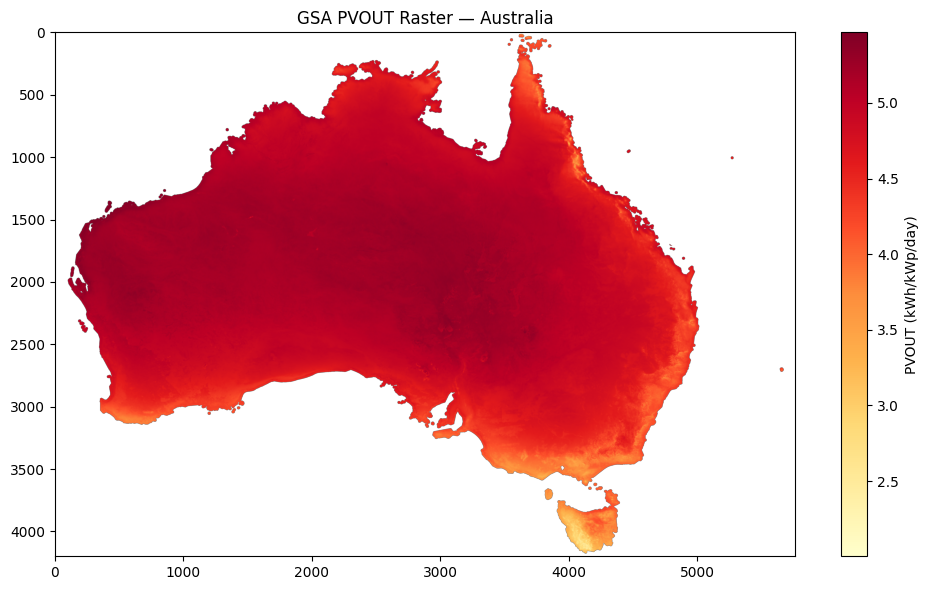

In [8]:
import rasterio
from rasterio.transform import rowcol

PVOUT_TIF = SOLAR_DIR / "PVOUT.tif"

with rasterio.open(PVOUT_TIF) as src:
    data = src.read(1)
    data = np.where(data == src.nodata, np.nan, data)

plt.figure(figsize=(10, 6))
plt.imshow(data, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="PVOUT (kWh/kWp/day)")
plt.title("GSA PVOUT Raster — Australia")
plt.tight_layout()
plt.show()

In [9]:
def extract_pvout(lat: float, lon: float, src) -> float:
    row, col = rowcol(src.transform, lon, lat)
    if row < 0 or col < 0 or row >= src.height or col >= src.width:
        return None
    value = src.read(1)[row, col]
    return None if value != value else float(value)  # NaN check


with rasterio.open(PVOUT_TIF) as src:
    print(f"CRS   : {src.crs}")
    print(f"Bounds: {src.bounds}")

    city_pvout = {
        city: extract_pvout(lat, lon, src) for city, (lat, lon) in city_coords.items()
    }

pvout_df = pd.Series(city_pvout).sort_values(ascending=False)
print(f"\nPVOUT extracted: {pvout_df.notna().sum()}/{len(pvout_df)} cities")
print(f"Range: {pvout_df.min():.2f} - {pvout_df.max():.2f} kWh/kWp/day")
print(pvout_df)

CRS   : EPSG:4326
Bounds: BoundingBox(left=112.0, bottom=-44.0, right=160.0, top=-9.0)

PVOUT extracted: 45/46 cities
Range: 3.63 - 5.25 kWh/kWp/day
AliceSprings        5.250
Woomera             5.042
Moree               4.862
Cobar               4.814
Townsville          4.809
Perth               4.763
PerthAirport        4.745
Mildura             4.739
PearceRAAF          4.735
Darwin              4.665
GoldCoast           4.605
Tuggeranong         4.577
SalmonGums          4.550
WaggaWagga          4.537
Canberra            4.511
Albury              4.451
MountGinini         4.449
Cairns              4.402
Nuriootpa           4.396
CoffsHarbour        4.394
Adelaide            4.387
Bendigo             4.363
Williamtown         4.361
Newcastle           4.347
NorahHead           4.303
Brisbane            4.302
Witchcliffe         4.201
SydneyAirport       4.195
BadgerysCreek       4.193
Penrith             4.155
Sydney              4.146
Wollongong          4.113
Launceston         

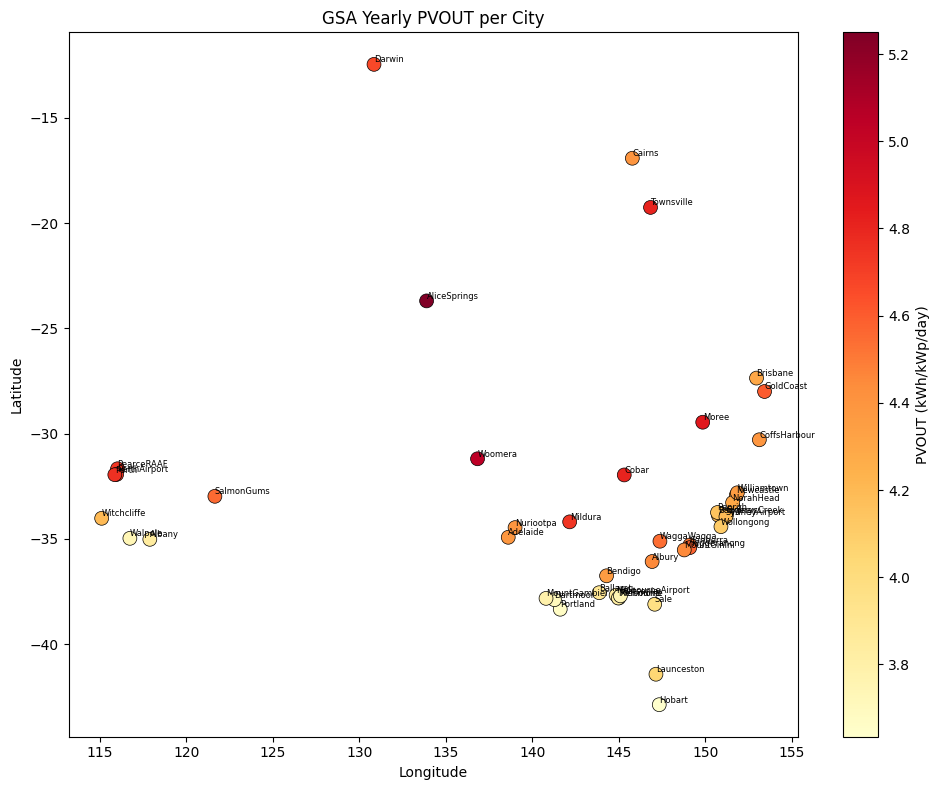

In [10]:
valid = {city: pvout for city, pvout in city_pvout.items() if pvout is not None}
lats = [city_coords[c][0] for c in valid]
lons = [city_coords[c][1] for c in valid]
vals = list(valid.values())

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    lons, lats, c=vals, cmap="YlOrRd", s=100, edgecolors="black", linewidths=0.5
)
plt.colorbar(scatter, label="PVOUT (kWh/kWp/day)")

for city, pvout in valid.items():
    lat, lon = city_coords[city]
    plt.annotate(city, (lon, lat), fontsize=6, ha="left", va="bottom")

plt.title("GSA Yearly PVOUT per City")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Map PVOUT city values onto each weather row as the target `y`. Drop any city without a PVOUT lookup (NorfolkIsland). Label-encode the four categorical columns (`WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`) using a shared encoder fitted on the train+holdout union to prevent unseen-label errors.

In [11]:
# Map PVOUT to each row by city
df_train["PVOUT"] = df_train["Location"].map(city_pvout)
df_holdout["PVOUT"] = df_holdout["Location"].map(city_pvout)

# Drop rows where PVOUT is None (NorfolkIsland)
df_train = df_train.dropna(subset=["PVOUT"])
df_holdout = df_holdout.dropna(subset=["PVOUT"])

print(f"Train shape   : {df_train.shape} | cities: {df_train['Location'].nunique()}")
print(
    f"Holdout shape : {df_holdout.shape} | cities: {df_holdout['Location'].nunique()}"
)
print(f"\nPVOUT distribution:")
print(df_train["PVOUT"].describe().round(3))

Train shape   : (16424, 24) | cities: 45
Holdout shape : (16417, 24) | cities: 45

PVOUT distribution:
count    16424.000
mean         4.309
std          0.395
min          3.634
25%          3.973
50%          4.361
75%          4.577
max          5.250
Name: PVOUT, dtype: float64


In [12]:
from sklearn.preprocessing import LabelEncoder

FEATURE_COLS = [c for c in df_train.columns if c not in ["Location", "PVOUT"]]
CAT_COLS = ["WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]

# Label encode categoricals
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([df_train[col], df_holdout[col]]).astype(str)
    le.fit(combined)
    df_train[col] = le.transform(df_train[col].astype(str))
    df_holdout[col] = le.transform(df_holdout[col].astype(str))
    encoders[col] = le

X_train = df_train[FEATURE_COLS]
y_train = df_train["PVOUT"]
X_test = df_holdout[FEATURE_COLS]
y_test = df_holdout["PVOUT"]

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Features: {FEATURE_COLS}")

X_train: (16424, 22)
X_test : (16417, 22)
Features: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Month', 'DayOfYear']


## 6. Model Training — Baseline XGBoost

Train an initial XGBoost regressor with sensible defaults (500 trees, lr=0.05, depth=6, subsample=0.8). Evaluate on the 2010 holdout split using RMSE, MAE, and R². Inspect feature importance and the predicted-vs-actual scatter to gauge model behaviour before tuning.

In [13]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=False,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

[0]	validation_0-rmse:0.38902
[100]	validation_0-rmse:0.27759
[200]	validation_0-rmse:0.26765
[300]	validation_0-rmse:0.26426
[400]	validation_0-rmse:0.26242
[499]	validation_0-rmse:0.26134

RMSE : 0.2613
MAE  : 0.1962
R²   : 0.5617


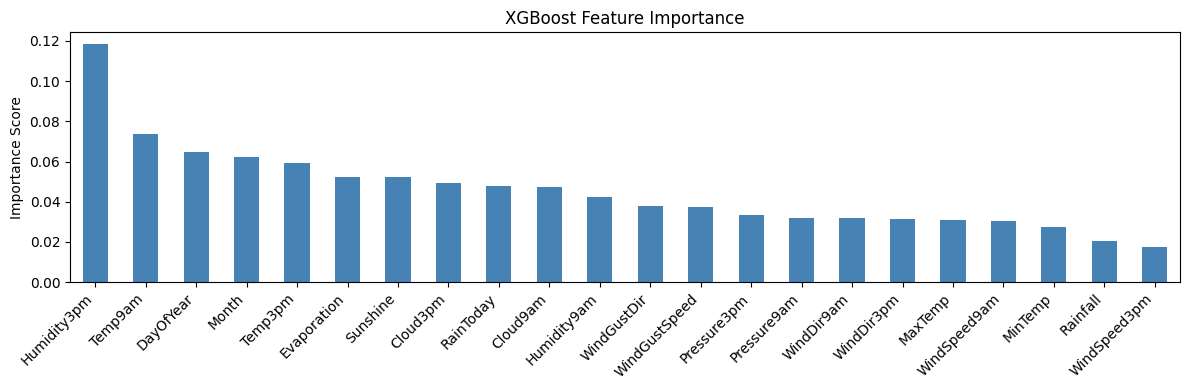

Humidity3pm      0.1184
Temp9am          0.0735
DayOfYear        0.0646
Month            0.0621
Temp3pm          0.0594
Evaporation      0.0523
Sunshine         0.0521
Cloud3pm         0.0492
RainToday        0.0479
Cloud9am         0.0472
Humidity9am      0.0426
WindGustDir      0.0378
WindGustSpeed    0.0375
Pressure3pm      0.0334
Pressure9am      0.0321
WindDir9am       0.0320
WindDir3pm       0.0313
MaxTemp          0.0310
WindSpeed9am     0.0305
MinTemp          0.0277
Rainfall         0.0202
WindSpeed3pm     0.0173
dtype: float32


In [14]:
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(
    ascending=False
)

importance.plot(kind="bar", figsize=(12, 4), color="steelblue")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(importance.round(4))

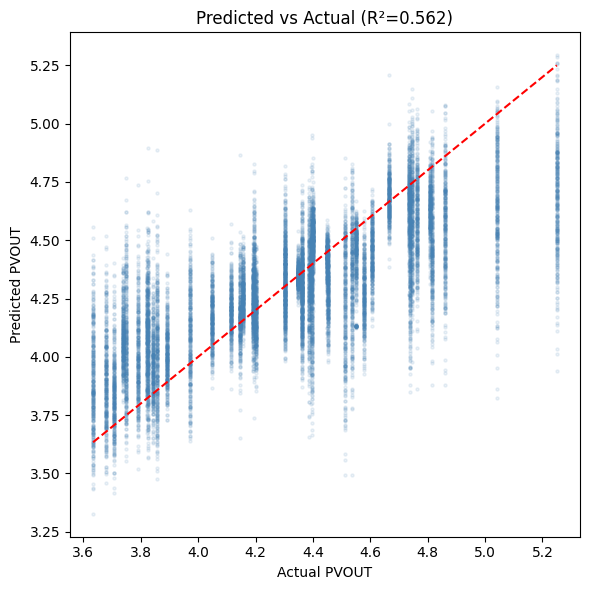

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.1, s=5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual PVOUT")
plt.ylabel("Predicted PVOUT")
plt.title(f"Predicted vs Actual (R²={r2:.3f})")
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning with Optuna

Run 100 trials of Bayesian optimisation (TPESampler) to maximise R² on the holdout set. Search space: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`.

In [16]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "n_jobs": -1,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    return r2_score(y_test, model.predict(X_test))


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best R²    : {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best R²    : 0.5840
Best params: {'n_estimators': 949, 'max_depth': 10, 'learning_rate': 0.019643798623062855, 'subsample': 0.8516789324828022, 'colsample_bytree': 0.7734267133213167, 'min_child_weight': 9}


In [17]:
best_model = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred_tuned = best_model.predict(X_test)
rmse_tuned = mean_squared_error(y_test, y_pred_tuned) ** 0.5
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Baseline → Tuned")
print(f"RMSE : {rmse:.4f} → {rmse_tuned:.4f}")
print(f"MAE  : {mae:.4f} → {mae_tuned:.4f}")
print(f"R²   : {r2:.4f} → {r2_tuned:.4f}")

Baseline → Tuned
RMSE : 0.2613 → 0.2546
MAE  : 0.1962 → 0.1872
R²   : 0.5617 → 0.5840


## 8. Save & Verify Artifacts

Persist all artifacts needed by the production agent to `data/processed/`:

| File | Contents |
|---|---|
| `xgb_model.json` | Tuned XGBoost model |
| `encoders.pkl` | LabelEncoder per categorical column |
| `city_pvout.pkl` | City → PVOUT lookup dict |
| `feature_cols.pkl` | Ordered feature column list |
| `holdout_weather.csv` | 2010 holdout rows (historical fallback for agent) |

Reload and re-score to confirm round-trip integrity.

In [18]:
import joblib

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

best_model.save_model(PROCESSED_DIR / "xgb_model.json")
joblib.dump(encoders, PROCESSED_DIR / "encoders.pkl")
joblib.dump(city_pvout, PROCESSED_DIR / "city_pvout.pkl")
joblib.dump(FEATURE_COLS, PROCESSED_DIR / "feature_cols.pkl")

# Raw holdout with Location and Date intact — agent uses for historical fallback
df_holdout_raw.to_csv(PROCESSED_DIR / "holdout_weather.csv", index=False)

print(
    "Saved: xgb_model.json, encoders.pkl, city_pvout.pkl, feature_cols.pkl, holdout_weather.csv"
)

Saved: xgb_model.json, encoders.pkl, city_pvout.pkl, feature_cols.pkl, holdout_weather.csv


In [19]:
# Reload everything to confirm saves are clean
model_loaded = xgb.XGBRegressor()
model_loaded.load_model(PROCESSED_DIR / "xgb_model.json")
encoders_loaded = joblib.load(PROCESSED_DIR / "encoders.pkl")
city_pvout_loaded = joblib.load(PROCESSED_DIR / "city_pvout.pkl")
feature_cols_loaded = joblib.load(PROCESSED_DIR / "feature_cols.pkl")
holdout_loaded = pd.read_csv(
    PROCESSED_DIR / "holdout_weather.csv", parse_dates=["Date"]
)

# Reconstruct X_test and y_test from loaded holdout
holdout_loaded["PVOUT"] = holdout_loaded["Location"].map(city_pvout_loaded)
holdout_loaded = holdout_loaded.dropna(subset=["PVOUT"])

CAT_COLS = ["WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]
for col in CAT_COLS:
    holdout_loaded[col] = encoders_loaded[col].transform(
        holdout_loaded[col].astype(str)
    )

X_test_reload = holdout_loaded[feature_cols_loaded]
y_test_reload = holdout_loaded["PVOUT"]

y_pred_reload = model_loaded.predict(X_test_reload)
r2_reload = r2_score(y_test_reload, y_pred_reload)

print(f"Model reload R²     : {r2_reload:.4f}")
print(f"Features            : {len(feature_cols_loaded)}")
print(f"Cities in city_pvout: {len(city_pvout_loaded)}")
print(f"Holdout shape       : {holdout_loaded.shape}")
print(
    f"Holdout date range  : {holdout_loaded['Date'].min()} to {holdout_loaded['Date'].max()}"
)

Model reload R²     : 0.5840
Features            : 22
Cities in city_pvout: 46
Holdout shape       : (16417, 27)
Holdout date range  : 2010-01-01 00:00:00 to 2010-12-31 00:00:00
